### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from matplotlib import pyplot as plt
from datetime import datetime
import re

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

c:\Users\huang\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# I-94: Monthly Arrrivals to the US Dataset

### Read in the Data 

In [2]:
file_path = './I94_monthly_arrivals.xlsx'

# Read the raw excel data
df_raw = pd.read_excel(file_path)

print("Dataset shape:", df_raw.shape)

Dataset shape: (257, 324)


### Inspect and Clean the Data

In [3]:
# Create a copy of raw data for cleaning
df = df_raw.copy()
print(df.shape)

(257, 324)


In [4]:
# See the first five rows
print(df.head())

     1  \
0  2.0   
1  3.0   
2  4.0   
3  5.0   
4  6.0   

  International Visitors--\n   1) Country of Residence\n   2) 1+ nights in the USA\n   3)  Among qualified visa types  \
0                                                NaN                                                                    
1                                TOTAL ALL COUNTRIES                                                                    
2                                                NaN                                                                    
3                                           OVERSEAS                                                                    
4                                                NaN                                                                    

  World \nRegion  2000-01-02 00:00:00  2000-02-03 00:00:00  \
0            NaN                  NaN                  NaN   
1            NaN            2866229.0            2948121.0   
2            NaN          

In [5]:
# Check the column names 
print(df.columns)

Index([                                                                                                                    1,
       'International Visitors--\n   1) Country of Residence\n   2) 1+ nights in the USA\n   3)  Among qualified visa types',
                                                                                                            'World \nRegion',
                                                                                                         2000-01-02 00:00:00,
                                                                                                         2000-02-03 00:00:00,
                                                                                                         2000-03-06 00:00:00,
                                                                                                         2000-04-07 00:00:00,
                                                                                                         2000-05-09 00

In [6]:
# Drop the first column (row numbers)
df = df.drop(columns=[df.columns[0]])

# Rename first two columns (countries/region)
df = df.rename(columns={df.columns[0]: 'Country', df.columns[1]: 'Region'})

# Check for missing values
print(f"Missing values in Country column: {df['Country'].isna().sum()}")
print(f"Missing values in Region column: {df['Region'].isna().sum()}")

Missing values in Country column: 8
Missing values in Region column: 22


In [7]:
# Drop empty rows/columns (rows/columns where ALL values are NaN)
# Replace empty strings and whitespace with NaN
df = df.replace('', pd.NA)
df = df.replace(r'^\s*$', pd.NA, regex=True)  # catches whitespace-only cells

# Now drop rows where ALL values are NaN
df = df.dropna(how='all')
df = df.dropna(axis=1, how='all')

# Delete unnecessary "Notes:" column
df = df.drop(columns=['Notes:'])
print(df.columns[:-1])
    
# Check updated df shape
print(f'Cleaned DataFrame shape: {df.shape}')

Index([             'Country',               'Region',    2000-01-02 00:00:00,
          2000-02-03 00:00:00,    2000-03-06 00:00:00,    2000-04-07 00:00:00,
          2000-05-09 00:00:00,    2000-06-10 00:00:00,    2000-07-12 00:00:00,
          2000-08-13 00:00:00,
       ...
                    '2025-07',              '2025-08',              '2025-09',
                    '2025-10',              '2025-11',              '2025-12',
                    '2026-01',              '2026-02',              '2026-03',
       '2026-04\nPreliminary'],
      dtype='object', length=318)
Cleaned DataFrame shape: (249, 319)


In [8]:
# Get all date columns (columns 2 onwards, excluding Country and Region)
date_columns = df.columns[2:]  # All columns after Country and Region

print(f"\nNumber of time periods (months): {len(date_columns)}")


Number of time periods (months): 317


In [9]:
# Check missing values in time series data
missing_in_dates = df[date_columns].isna().sum().sum()
total_date_cells = df[date_columns].size
print(f"Missing values in time series data: {missing_in_dates:,} out of {total_date_cells:,} ({100*missing_in_dates/total_date_cells:.1f}%)")

# Missing values seems to indicate no data collected. For the sake of analysis, we'll fill those with zeros
df[date_columns] = df[date_columns].apply(pd.to_numeric, errors='coerce').fillna(0)

Missing values in time series data: 3,876 out of 78,933 (4.9%)


In [10]:
# Clean our date_columns to all have the same format (YYYY-MM)
new_columns = []

for col in df.columns:
    if col in date_columns:
        # Handle actual datetime/Timestamp objects already in columns
        if isinstance(col, (datetime, pd.Timestamp)):
            new_columns.append(col.strftime("%m-%Y"))
            continue
            
        # Handle strings (cleaning "Preliminary")
        clean_col = str(col).replace("Preliminary", "").strip()

        # Try MM/DD/YYYY
        try:
            new_columns.append(datetime.strptime(clean_col, "%m/%d/%Y").strftime("%m-%Y"))
            continue
        except ValueError:
            pass

        # Try MM-YYYY
        try:
            new_columns.append(datetime.strptime(clean_col, "%m-%Y").strftime("%m-%Y"))
            continue
        except ValueError:
            pass
            
        # If string doesn't match above but is in date_columns, keep original string
        new_columns.append(col)
    else:
        # Keep non-date columns exactly as they are
        new_columns.append(col)

df.columns = new_columns

# update date_columns to reflect new_columns
date_columns = df.columns[2:]

In [11]:
# Optional: save cleaned data to a new Excel file:
df.to_excel('./I94_monthly_arrivals_cleaned.xlsx', index=False)

print("File saved successfully!")

File saved successfully!


We will now extract the date and arrivals for Y (labels) for modeling later on

In [12]:
# Load workbook
df_i94_raw = pd.read_excel("I94_monthly_arrivals_cleaned.xlsx")

# Clean whitespace in header labels
df_i94_raw.columns = df_i94_raw.columns.astype(str).str.strip()

# Locate the existing total-arrivals row
total_row = df_i94_raw.loc[
    df_i94_raw["Country"].astype(str).str.strip().str.upper()
    == "TOTAL ALL COUNTRIES"
]

records = []

for column in df_i94_raw.columns:
    column_clean = str(column).strip()

    # Accept both formats:
    # 01-2000 / 1-2000
    # 2017-01 / 2022-1
    if re.fullmatch(r"\d{1,2}-\d{4}|\d{4}-\d{1,2}", column_clean):

        # Pandas can parse either year-month or month-year formats here
        date = pd.to_datetime(column_clean, errors="coerce")

        # For dates like 01-2000 that pandas may interpret inconsistently,
        # explicitly parse as month-year.
        if re.fullmatch(r"\d{1,2}-\d{4}", column_clean):
            date = pd.to_datetime(column_clean, format="%m-%Y")

        total_arrivals = total_row[column].iloc[0]

        records.append({
            "date": date,
            "total_arrivals": total_arrivals
        })

df_arrivals = pd.DataFrame(records)

# Ensure target values are numeric
df_arrivals["total_arrivals"] = pd.to_numeric(
    df_arrivals["total_arrivals"],
    errors="coerce"
)

# Add time features
df_arrivals["year"] = df_arrivals["date"].dt.year
df_arrivals["month"] = df_arrivals["date"].dt.month

# Restrict to the project period
df_arrivals = (
    df_arrivals[
        (df_arrivals["year"] >= 2000)
        & (df_arrivals["year"] <= 2026)
    ]
    .dropna(subset=["date", "total_arrivals"])
    .sort_values("date")
    .reset_index(drop=True)
)

print(df_arrivals.head())
print(df_arrivals.tail())
print(df_arrivals.shape)

        date  total_arrivals  year  month
0 2000-01-01       2866229.0  2000      1
1 2000-02-01       2948121.0  2000      2
2 2000-03-01       3709993.0  2000      3
3 2000-04-01       4108278.0  2000      4
4 2000-05-01       3712454.0  2000      5
          date  total_arrivals  year  month
310 2025-11-01       5317965.0  2025     11
311 2025-12-01       6048545.0  2025     12
312 2026-01-01       5412343.0  2026      1
313 2026-02-01       4660883.0  2026      2
314 2026-03-01       5537310.0  2026      3
(315, 4)


In [13]:
# Optional: save arrivals data to a new CSV file:
df_arrivals.to_csv('./label_arrivals_cleaned.csv', index=False)

print("File saved successfully!")

File saved successfully!


### Exploratory Data Analysis (EDA)

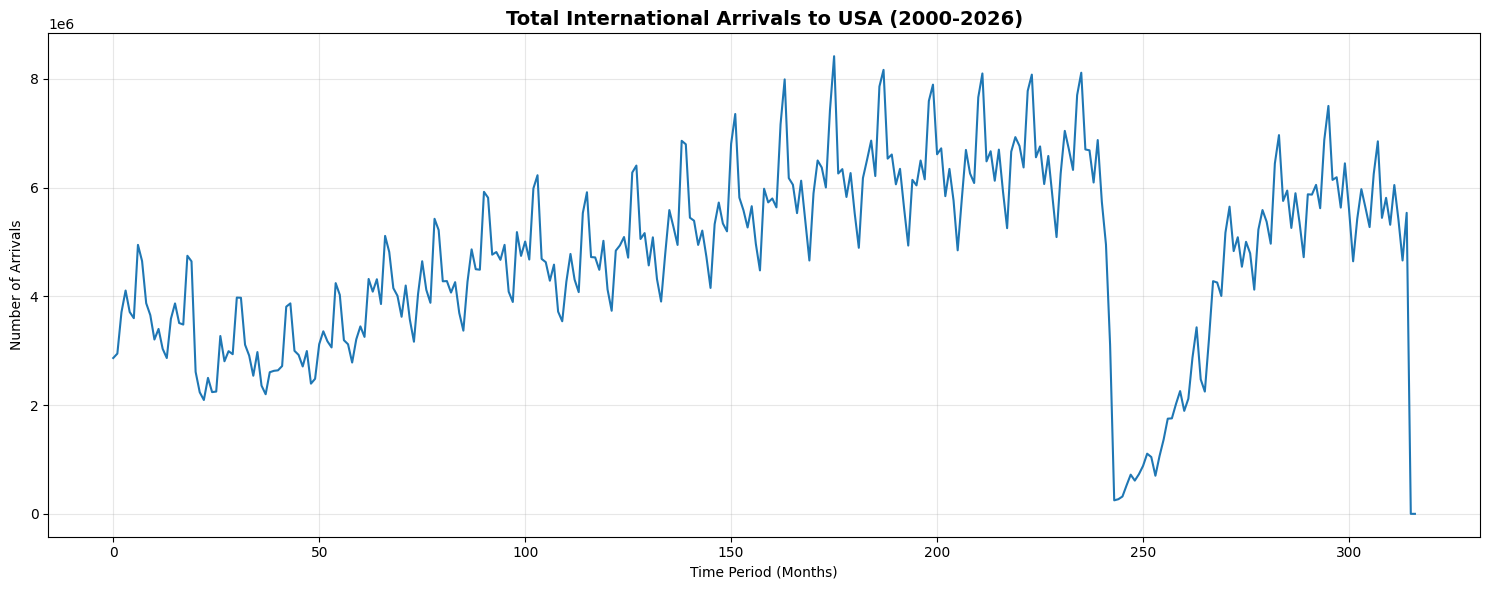

In [14]:
# Extract total arrivals over time
total_row = df[df['Country'] == 'TOTAL ALL COUNTRIES'].iloc[0]
total_data = total_row[date_columns].values

# Create time series plot
plt.figure(figsize=(15, 6))
plt.plot(total_data)
plt.title('Total International Arrivals to USA (2000-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Time Period (Months)')
plt.ylabel('Number of Arrivals')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

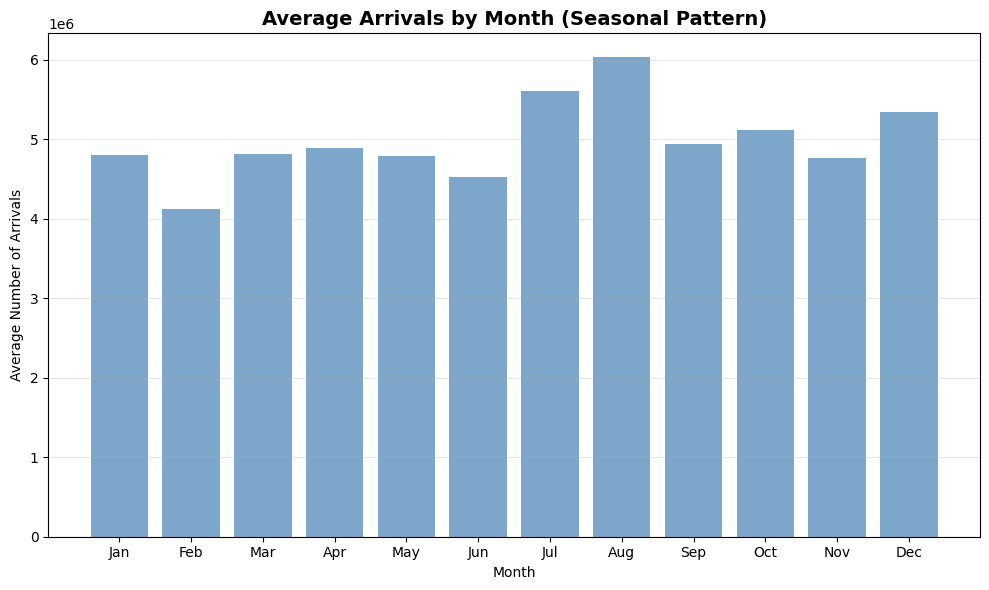

In [15]:
# Analyze seasonality - extract month from column names and aggregate
# This requires parsing the date columns properly

# Calculate monthly averages across all years
monthly_avg = {}
for col in date_columns:
    col_str = str(col)
    # Extract month number from column name
    try:
        if '-' in col_str:
            month = int(col_str.split('-')[1])
            if month not in monthly_avg:
                monthly_avg[month] = []
            monthly_avg[month].append(total_row[col])
    except:
        pass

# Plot seasonality
months = sorted([m for m in monthly_avg.keys() if 1 <= m <= 12])
avg_values = [np.nanmean(monthly_avg[m]) for m in months]

plt.figure(figsize=(10, 6))
plt.bar(months, avg_values, color='steelblue', alpha=0.7)
plt.title('Average Arrivals by Month (Seasonal Pattern)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Number of Arrivals')
plt.xticks(months, ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Top 20 Source Countries (2000-2026):
            Country          Region        Total
54           Canada   North America  448861163.0
154          Mexico   North America  335573106.0
239  United Kingdom  Western Europe  103690873.0
123           Japan            Asia   80708507.0
96          Germany  Western Europe   42944905.0
46           Brazil   South America   32945074.0
90           France  Western Europe   32908738.0
209     South Korea            Asia   31119047.0
60            China            Asia   31055339.0
113           India            Asia   23135862.0
29        Australia         Oceania   22268139.0
121           Italy  Western Europe   19941280.0
63         Colombia   South America   17131484.0
211           Spain  Western Europe   15741047.0
166     Netherlands  Western Europe   13966578.0
26        Argentina   South America   13807854.0
243       Venezuela   South America   11252958.0
119         Ireland  Western Europe   10069407.0
222     Switzerland  Western Eur

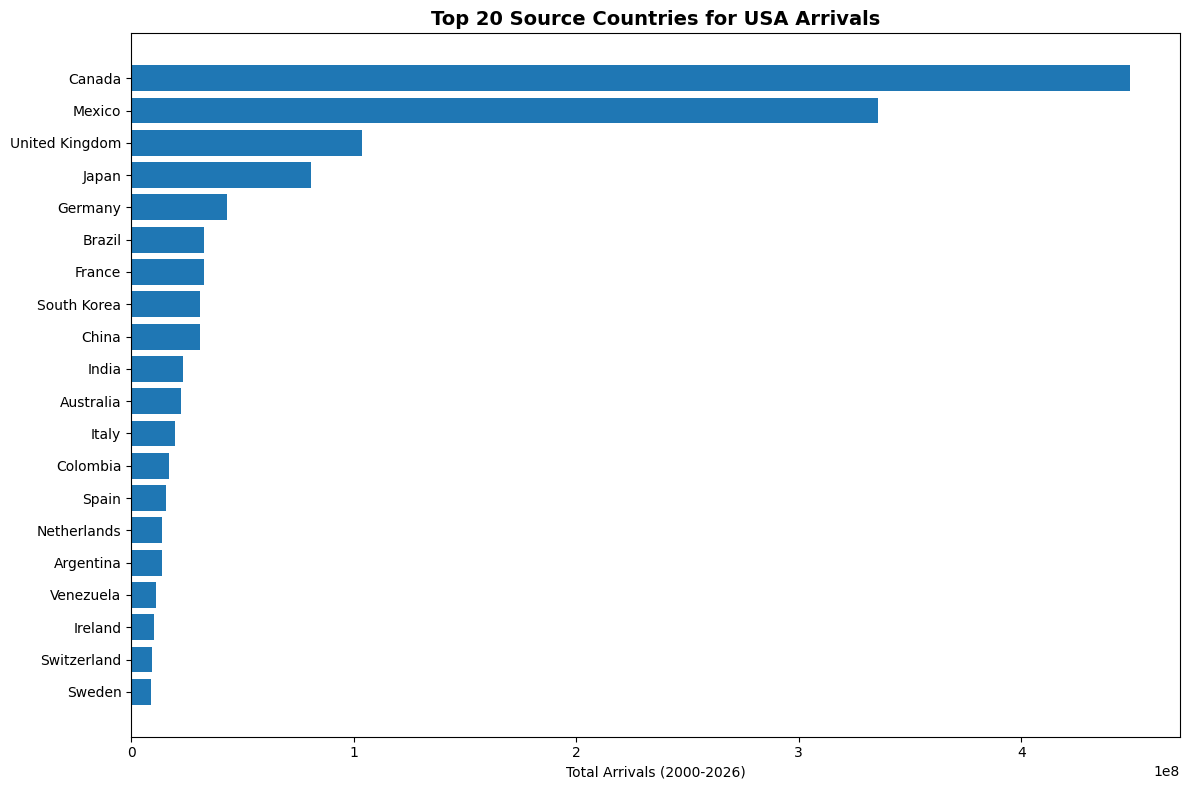

In [16]:
# Calculate total arrivals per country across all time periods
country_totals = df[df['Region'].notna()].copy()  # Only individual countries
country_totals['Total'] = country_totals[date_columns].sum(axis=1)
country_totals_sorted = country_totals[['Country', 'Region', 'Total']].sort_values('Total', ascending=False)

# Display top 20 countries
print("Top 20 Source Countries (2000-2026):")
print(country_totals_sorted.head(20))

# Visualize
plt.figure(figsize=(12, 8))
top_20 = country_totals_sorted.head(20)
plt.barh(range(20), top_20['Total'].values)
plt.yticks(range(20), top_20['Country'].values)
plt.xlabel('Total Arrivals (2000-2026)')
plt.title('Top 20 Source Countries for USA Arrivals', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

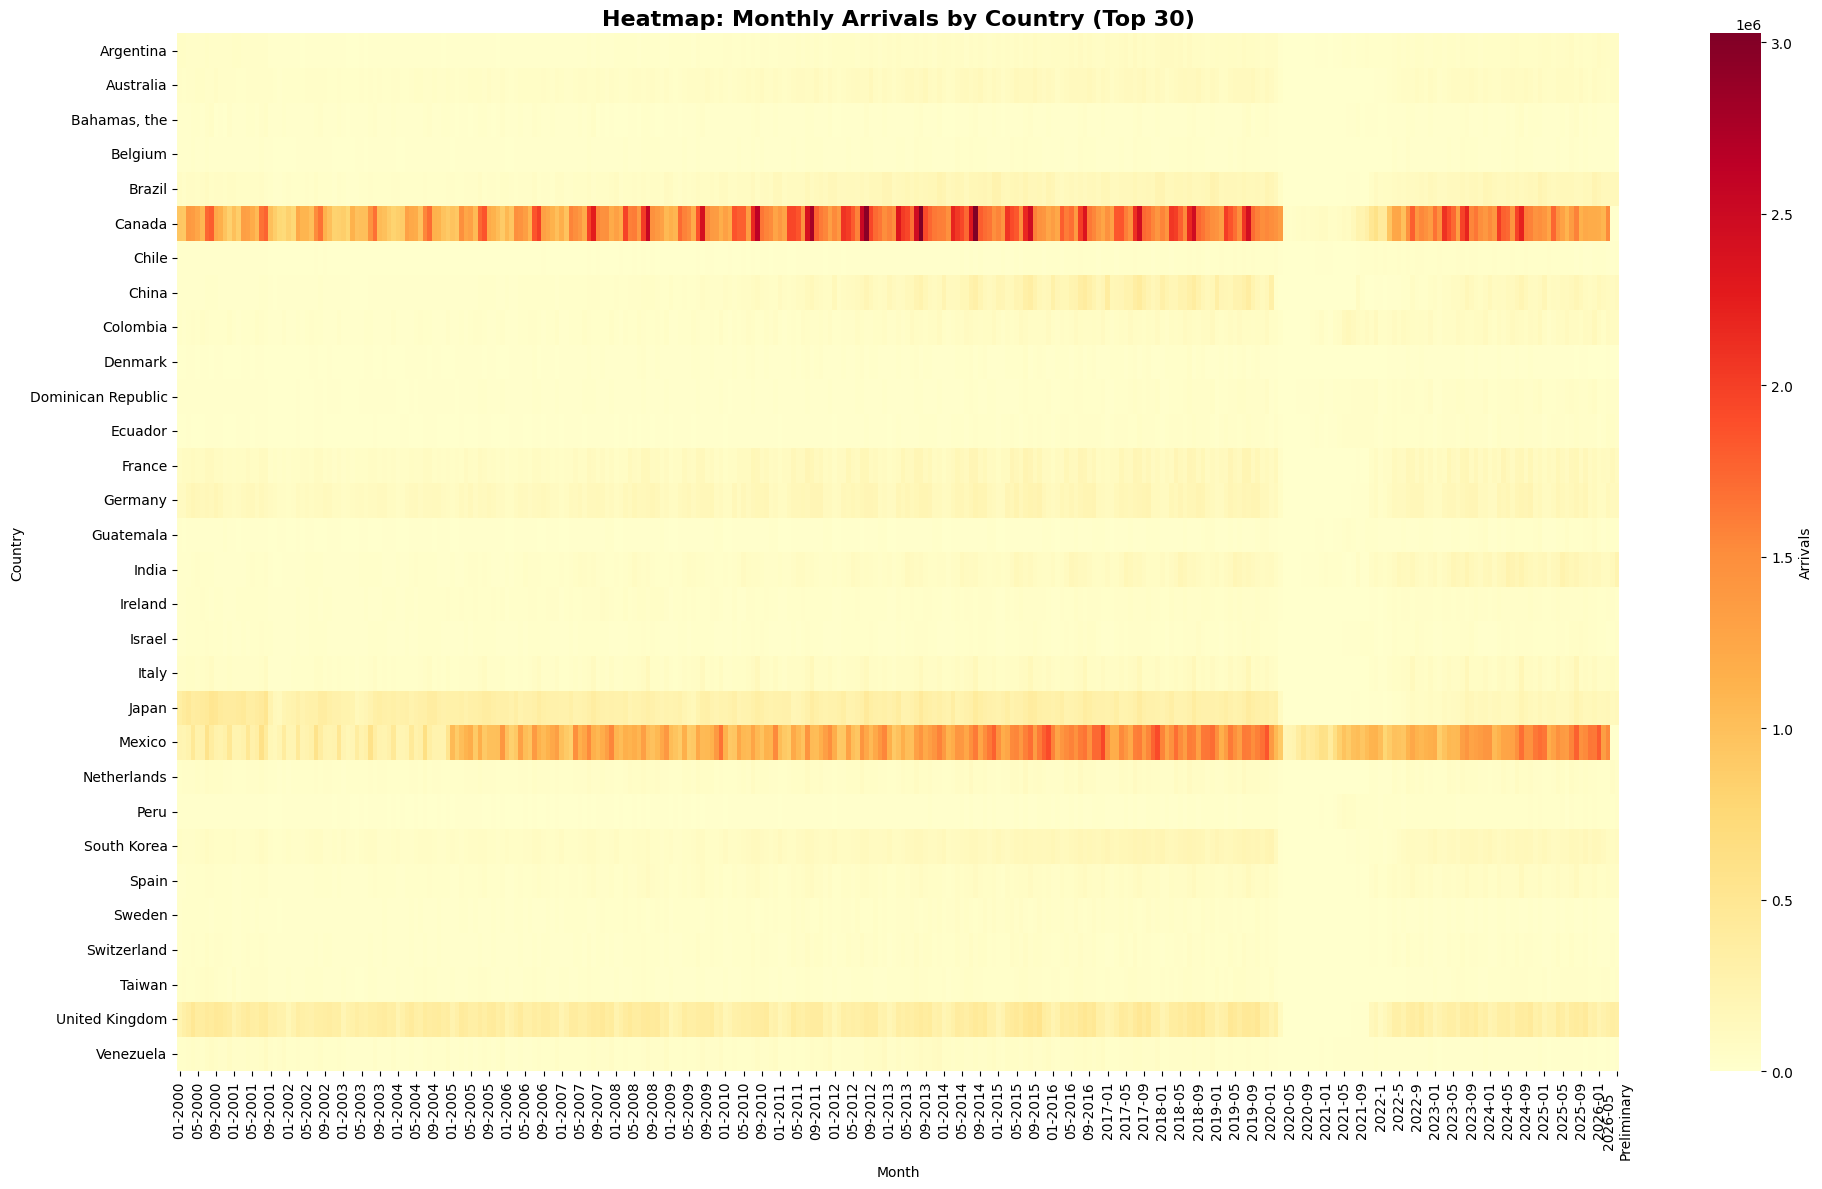

In [17]:
# Create a heatmap showing arrivals by country over time
# Countries on Y-axis, time on X-axis, color = arrival count

# Select top 30 countries for readability
# TODO: Adjust the heatmap to indicate arrivals/population
top_30_countries = country_totals_sorted.head(30)['Country'].values
heatmap_data = df[df['Country'].isin(top_30_countries)].set_index('Country')[date_columns]

plt.figure(figsize=(20, 12))
sns.heatmap(heatmap_data, cmap='YlOrRd', cbar_kws={'label': 'Arrivals'})
plt.title('Heatmap: Monthly Arrivals by Country (Top 30)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# US Political Party in Control (President/Congress) Dataset

### Read in the Dataset

In [18]:
df_party_raw = pd.read_csv("./feature_party_cleaned.csv")
print(df_party_raw.shape)

(85, 6)


### Inspect and Clean Political Party Dataset

In [19]:
df_party = df_party_raw.copy()
print(df_party.head())

   congress      years house_majority senate_majority  \
0        35  1857-1859      Democrats       Democrats   
1        36  1859-1861    Republicans       Democrats   
2        37  1861-1863    Republicans     Republicans   
3        38  1863-1865    Republicans     Republicans   
4        39  1865-1867    Republicans     Republicans   

                                     presidency   party_government  
0                           Democrat (Buchanan)            Unified  
1                           Democrat (Buchanan)            Divided  
2                          Republican (Lincoln)            Unified  
3                          Republican (Lincoln)            Unified  
4  Republican (Lincoln) / Democrat (A. Johnson)  Unified / Divided  


In [20]:
print(df_party.columns.tolist())

['congress', 'years', 'house_majority', 'senate_majority', 'presidency', 'party_government']


In [21]:
# Create additional df columns for convenience; convert values to int as needed
df_party["is_unified"] = df_party["party_government"].str.contains("Unified")
df_party["house_rep"] = df_party["house_majority"].eq("Republicans")
df_party["senate_rep"] = df_party["senate_majority"].str.startswith("Republicans")
df_party["president_rep"] = df_party["presidency"].str.startswith("Republican")
df_party["start_year"] = df_party["years"].str[:4].astype(int)
df_party["end_year"] = df_party["years"].str[-4:].astype(int)

In [22]:
# We are only going to be interested in data from 1999 onward, so drop all rows prior 
df_party = df_party[df_party["start_year"] >= 1999].reset_index(drop=True)
print(df_party.head)

<bound method NDFrame.head of     congress      years house_majority          senate_majority  \
0        106  1999-2001    Republicans              Republicans   
1        107  2001-2003    Republicans  Republicans / Democrats   
2        108  2003-2005    Republicans              Republicans   
3        109  2005-2007    Republicans              Republicans   
4        110  2007-2009      Democrats                Democrats   
5        111  2009-2011      Democrats                Democrats   
6        112  2011-2013    Republicans                Democrats   
7        113  2013-2015    Republicans                Democrats   
8        114  2015-2017    Republicans              Republicans   
9        115  2017-2019    Republicans              Republicans   
10       116  2019-2021      Democrats              Republicans   
11       117  2021-2023      Democrats                Democrats   
12       118  2023-2025    Republicans                Democrats   
13       119  2025-2027    Repub

### Exploratory Data Analysis (EDA)

In [23]:
# Create a heatmap showing which party controls what from 1999 to 2025
heatmap_df = df_party.copy()

heatmap_df["House"] = heatmap_df["house_majority"].eq("Republicans").astype(int)
heatmap_df["Senate"] = heatmap_df["senate_majority"].str.startswith("Republicans").astype(int)
heatmap_df["President"] = heatmap_df["presidency"].str.startswith("Republican").astype(int)

heatmap_df = heatmap_df.set_index("start_year")[["House", "Senate", "President"]]

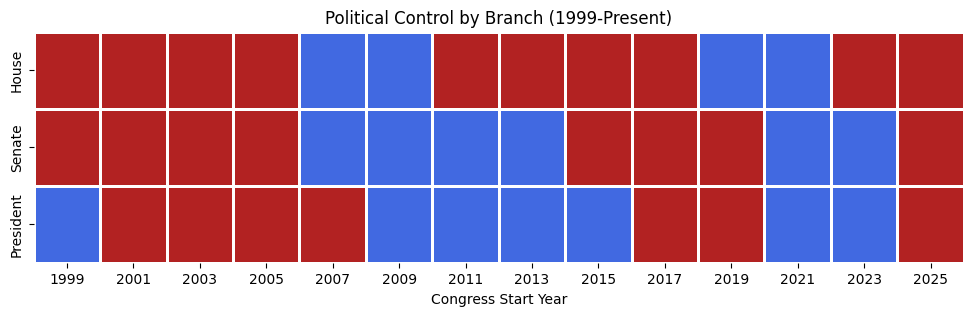

In [24]:
# Plot the heatmap
# TODO: Use this heatmap as a background on top of other metrics in I-94 data
plt.figure(figsize=(12,3))

sns.heatmap(
    heatmap_df.T,
    cmap=["royalblue", "firebrick"],
    cbar=False,
    linewidths=1,
    linecolor="white"
)

plt.title("Political Control by Branch (1999-Present)")
plt.xlabel("Congress Start Year")
plt.ylabel("")
plt.show()

## Baseline Modeling

#### We plan to use some form of linear regression to form our baseline. This will be the metric which we compare future model improvements to

In [25]:
# TODO: Combine Features to create X 
# X: features (combined?). We have a mix of annual/monthly features. 
# Y: I-94 arrivals by month from 2000-2026. We will keep data monthly and apply features equally across each month
# in a year

X_train, X_test, Y_train, Y_test = train_test_split...

SyntaxError: invalid syntax (851588688.py, line 6)

In [ ]:
# TODO: Create a function for baseline modeling (use either or both options)
# Option 1: Create a dummy model that predicts Y_train.avg() every time 
base_model = Y_train.avg()
base_model.fit(X_train, Y_train)

# Option 2: Use sckitlearn LinearRegression()
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

In [ ]:
# TODO: Output results, accuracy 
Y_base_model = base_model.predict(X_test)
Y_linear_model = linear_model.predict(X_test)

# TODO: Accuracy computations using MSE
Y_train_pred_majority_baseline = df_train.apply(majority_baseline, axis=1)
Y_train_pred_rule_baseline = df_train.apply(rule_baseline, axis=1)
Y_dev_pred_majority_baseline = df_dev.apply(majority_baseline, axis=1)
Y_dev_pred_rule_baseline = df_dev.apply(rule_baseline, axis=1)

Y_train = df_train['Survived']

print('Majority baseline train accuracy: %.3f'
  %(np.sum(Y_train_pred_majority_baseline == Y_train) / len(Y_train)))
print('Majority baseline dev accuracy:   %.3f'
  %(np.sum(Y_dev_pred_majority_baseline == Y_dev) / len(Y_dev)))
print('Rule baseline train accuracy:     %.3f'
  %(np.sum(Y_train_pred_rule_baseline == Y_train) / len(Y_train)))
print('Rule baseline dev accuracy:       %.3f'
  %(np.sum(Y_dev_pred_rule_baseline == Y_dev) / len(Y_dev)))

## Improving on our Baseline

#### Build Model framework using embeddings

In [ ]:
def build_model():
  # Clear session and remove randomness.
  tf.keras.backend.clear_session()
  tf.random.set_seed(0)

  age = tf.keras.layers.Input(shape=(1,), dtype=tf.float32, name='Age')
  sex = tf.keras.layers.Input(shape=(1,), dtype=tf.string, name='Sex')
  pclass = tf.keras.layers.Input(shape=(1,), dtype=tf.int64, name='Pclass')
  emb = tf.keras.layers.Input(shape=(1,), dtype=tf.string, name='Embarked')

  age_bins = [0.1, 1, 5, 10, 20, 30, 40, 50, 60]
  age_binned = tf.keras.layers.Discretization(bin_boundaries=age_bins)(age)
  age_id = tf.keras.layers.IntegerLookup(
      vocabulary=np.arange(0, len(age_bins)+1),
      output_mode='one_hot')(age_binned)

  sex_id = tf.keras.layers.StringLookup(
      vocabulary=['male', 'female'], output_mode='one_hot')(sex)

  pclass_id = tf.keras.layers.IntegerLookup(
      vocabulary=[1, 2, 3], output_mode='one_hot')(pclass)

  emb_id = tf.keras.layers.StringLookup(
      vocabulary=['S', 'C', 'Q'], output_mode='one_hot')(emb)
  
  features = tf.keras.layers.Concatenate()([age_id, sex_id, pclass_id, emb_id])
  
  dense = tf.keras.layers.Dense(
      units=12, activation='tanh', name='hidden1')(features)
  
  survived = tf.keras.layers.Dense(
      units=1, activation='sigmoid', name='Survived')(dense)

  model = tf.keras.Model(inputs=[age, sex, pclass, emb],
                         outputs=survived,
                         name='Titanic')
  model.compile(
      optimizer=tf.keras.optimizers.Adam(learning_rate=0.02),
      loss='binary_crossentropy',
      metrics=['accuracy'])

  return model